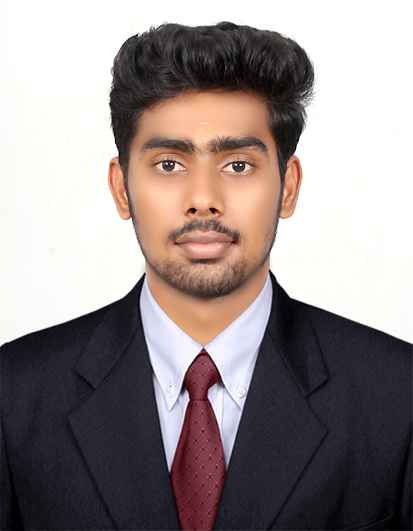

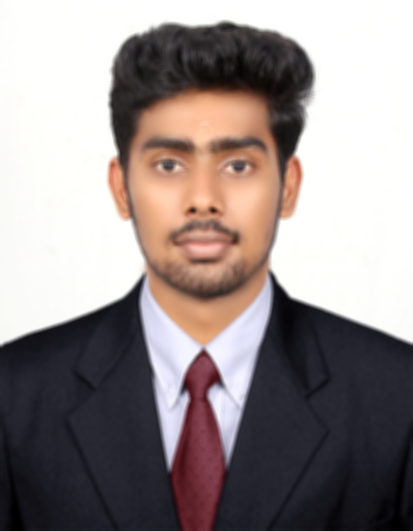

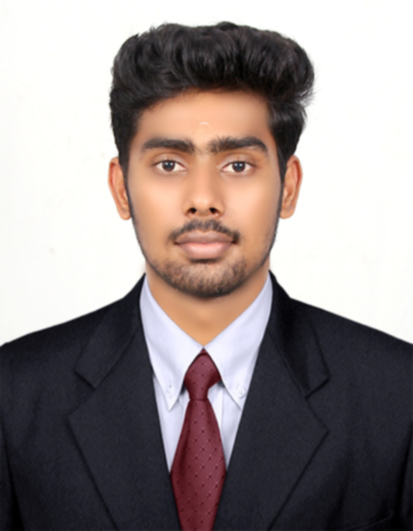

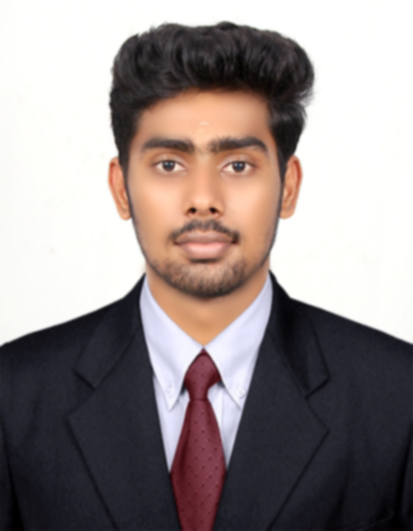

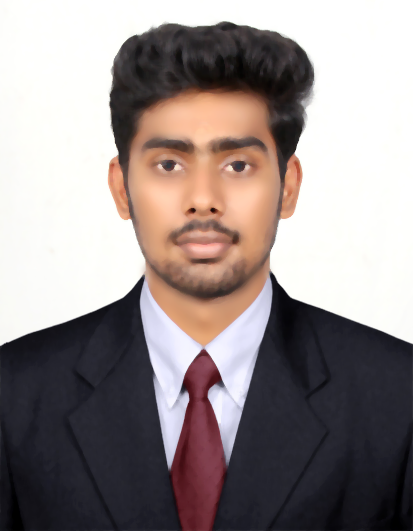

In [3]:

# expt-5(a)-smoothing filters - Average, Weighted Average, Gaussian and Median

import cv2
import numpy as np
from google.colab.patches import cv2_imshow


# Load the image
image = cv2.imread("/content/LOGU PASSPORT IMAGE.png")  # Replace with your actual image path
if image is None:
    raise ValueError("Image not found. Check the file path.")

# ------------------ 1. Averaging Filter ------------------
average_blur = cv2.blur(image, (5, 5))  # Kernel size (5x5)

# ------------------ 2. Weighted Averaging Filter ------------------
# Custom kernel (normalized)
kernel = np.array([[1, 2, 1],
                   [2, 4, 2],
                   [1, 2, 1]], dtype=np.float32)
kernel /= np.sum(kernel)
weighted_blur = cv2.filter2D(image, -1, kernel)

# ------------------ 3. Gaussian Filter ------------------
gaussian_blur = cv2.GaussianBlur(image, (5, 5), 0)

# ------------------ 4. Median Filter ------------------
median_blur = cv2.medianBlur(image, 5)  # Kernel size must be odd

# ------------------ Display Results ------------------
cv2_imshow(image)
cv2_imshow(average_blur)
cv2_imshow(weighted_blur)
cv2_imshow(gaussian_blur)
cv2_imshow(median_blur)

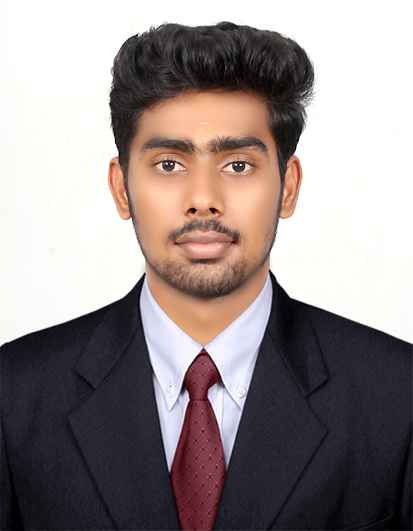

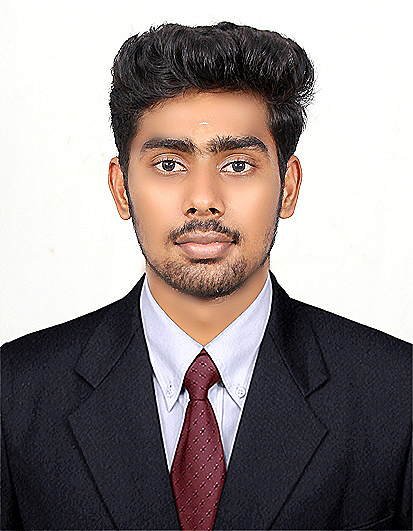

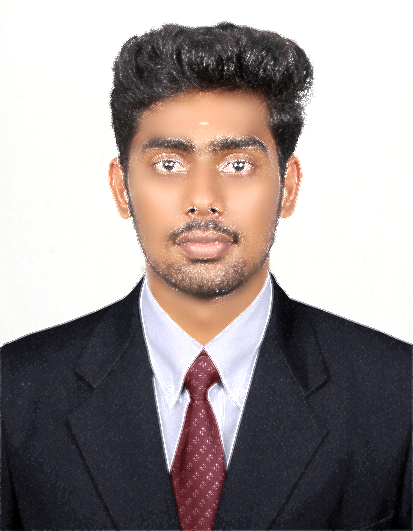

In [7]:
import cv2
import numpy as np

# Load the image
image = cv2.imread('/content/LOGU PASSPORT IMAGE.png')  # Replace with your actual image path
if image is None:
    raise ValueError("Image not found. Check the file path.")

# Convert to grayscale (for Laplacian Operator)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ------------------ 1. Sharpening with Laplacian Linear Kernel ------------------
# Define a sharpening kernel using Laplacian
laplacian_kernel = np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]], dtype=np.float32)

# Apply the kernel using filter2D
sharpened_kernel = cv2.filter2D(image, -1, laplacian_kernel)

# ------------------ 2. Sharpening with Laplacian Operator ------------------
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

# Convert grayscale laplacian to 3-channel to add back to color image
laplacian_color = cv2.merge([laplacian] * 3)

# Add Laplacian details to the original image to enhance edges
sharpened_operator = cv2.addWeighted(image, 1.0, laplacian_color, 1.0, 0)

# ------------------ Display Results ------------------
cv2_imshow(image)
cv2_imshow(sharpened_kernel)
cv2_imshow(sharpened_operator)

cv2.waitKey(0)
cv2.destroyAllWindows()